# Peak Analysis Workflow

This tutorial shows an end-to-end peak-analysis workflow in SpectroChemPy:

1. prepare a spectrum,
2. detect peaks with `find_peaks()`,
3. inspect the result through `PeakFindingResult` and `PeakTable`,
4. export the table,
5. write and validate a fitting script,
6. fit the spectrum and inspect the resulting `FitResult`.

It complements the dedicated tutorials on
[peak finding](peak_finding.py) and [fitting](fitting.py) by focusing on the
bridge between detection and fitting.

In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import spectrochempy as scp

## Load and prepare a spectrum

We build a small synthetic spectrum with two broad OH-like peaks on top of a
gentle baseline and a little Gaussian noise. This keeps the tutorial
self-contained while still showing the full workflow on a slightly more
realistic profile.

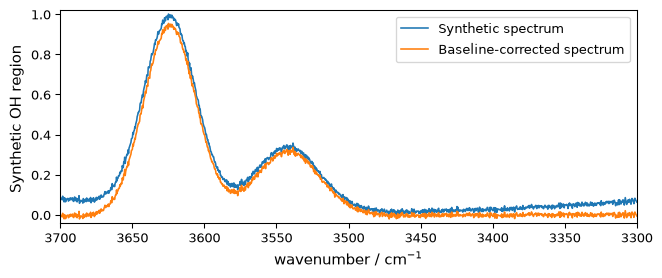

In [2]:
prefs = scp.preferences
prefs.figure.figsize = (7, 3)

x = scp.Coord.linspace(3700.0, 3300.0, 1200, title="wavenumber", units="cm^-1")
baseline = scp.polynomial(
    x,
    offset=0.015,
    slope=0.00002,
    ampl=1.0,
    c_2=1.5e-6,
)
peak_1 = scp.gaussian(x, ampl=0.95, pos=3624.0, width=42.39, normalized=False)
peak_2 = scp.gaussian(x, ampl=0.32, pos=3542.0, width=51.81, normalized=False)
noise = scp.normal(loc=0.0, scale=0.007, size=x.size)

nd_oh = baseline + peak_1 + peak_2 + noise
nd_oh.title = "Synthetic OH region"

nd_oh_corr = scp.basc(
    nd_oh,
    [3700.0, 3670.0],
    [3490.0, 3300.0],
    model="polynomial",
    order=2,
)
ax = nd_oh.plot(label="Synthetic spectrum")
_ = nd_oh_corr.plot(clear=False, label="Baseline-corrected spectrum")
ax.legend()

## Detect peaks and inspect the structured result

`find_peaks(..., as_result=True)` returns a `PeakFindingResult` instead of the
historical `(peaks, properties)` tuple.  The result keeps the detected peak
dataset and exposes a stable tabular view through `result.table`.

In [3]:
result = nd_oh_corr.find_peaks(
    height=0.05,
    distance="20 cm^-1",
    prominence=0.1,
    width="10 cm^-1",
    as_result=True,
)
result

PeakFindingResult(n_peaks=2)

In [4]:
table = result.table
table

PeakTable(n_peaks=2)

`PeakTable` gives us a dependency-light view of the detected peaks.  The raw
peak dataset and the raw SciPy-style property dictionary are still available on
`result`, but the table is often a better starting point for inspection,
export, and later workflow steps.

In [5]:
rows = table.to_dict()
rows[:4]

[{'index': 0,
  'position': <Quantity(3624.816, '1 / centimeter')>,
  'height': 0.9565411694347858,
  'peak_height': 0.9543790923204394,
  'prominence': 0.9748951332061883,
  'left_base': <Quantity(3686.656, '1 / centimeter')>,
  'right_base': <Quantity(3471.81, '1 / centimeter')>,
  'width': <Quantity(42.2627383, '1 / centimeter')>,
  'width_height': 0.46693152571734525,
  'left_ip': <Quantity(3644.94501, '1 / centimeter')>,
  'right_ip': <Quantity(3602.68057, '1 / centimeter')>},
 {'index': 1,
  'position': <Quantity(3538.492, '1 / centimeter')>,
  'height': 0.33609869913198054,
  'peak_height': 0.3358449896273052,
  'prominence': 0.24014586630637494,
  'left_base': <Quantity(3576.897, '1 / centimeter')>,
  'right_base': <Quantity(3471.81, '1 / centimeter')>,
  'width': <Quantity(36.2527467, '1 / centimeter')>,
  'width_height': 0.21577205647411773,
  'left_ip': <Quantity(3560.44964, '1 / centimeter')>,
  'right_ip': <Quantity(3524.1961, '1 / centimeter')>}]

We can also look at the available table columns:

In [6]:
table.columns

('index',
 'position',
 'height',
 'peak_height',
 'prominence',
 'left_base',
 'right_base',
 'width',
 'width_height',
 'left_ip',
 'right_ip')

## Export the peak table

`PeakTable.to_csv()` writes a simple CSV file without adding any optional
dependency such as pandas.

In [7]:
with TemporaryDirectory() as tmpdir:
    csv_path = Path(tmpdir) / "nh4y-oh-peaks.csv"
    _ = table.to_csv(csv_path)
    preview = "\n".join(csv_path.read_text(encoding="utf-8").splitlines()[:4])

print(preview)

index,position,height,peak_height,prominence,left_base,right_base,width,width_height,left_ip,right_ip
0,3624.816 cm⁻¹,0.9565411694347858,0.9543790923204394,0.9748951332061883,3686.656 cm⁻¹,3471.81 cm⁻¹,42.262738285624344 cm⁻¹,0.46693152571734525,3644.9450084680198 cm⁻¹,3602.680568434652 cm⁻¹
1,3538.492 cm⁻¹,0.33609869913198054,0.3358449896273052,0.24014586630637494,3576.897 cm⁻¹,3471.81 cm⁻¹,36.25274668477797 cm⁻¹,0.21577205647411773,3560.4496435405053 cm⁻¹,3524.1960996375346 cm⁻¹


## Select starting candidates for fitting

Peak detection gives geometric candidates.  Fitting still requires a modeling
decision: which peaks do we want to fit, with which line shape, and with which
bounds?  Here we keep the two strongest detected peaks and use their positions
as initial guesses in a manually written fitting script.

In [8]:
selected_table = table.top(2, by="height").sort_by(
    "position",
    reverse=True,
    unit="cm^-1",
)
positions = selected_table.column("position", unit="cm^-1", as_float=True)
heights = selected_table.column("height", as_float=True)
widths = selected_table.column("width", unit="cm^-1", as_float=True)

for position, height, width in zip(positions, heights, widths, strict=False):
    print(
        f"candidate peak at {position:.2f} cm^-1 "
        f"with height {height:.3f} and width {width:.2f} cm^-1"
    )

candidate peak at 3624.82 cm^-1 with height 0.957 and width 42.26 cm^-1
candidate peak at 3538.49 cm^-1 with height 0.336 and width 36.25 cm^-1


In [9]:
script = f"""
COMMON:
$ gratio: 0.1, 0.0, 1.0
$ gasym: 0.1, 0.0, 1.0

MODEL: LINE_1
shape: asymmetricvoigtmodel
    $ ampl:  1.0, 0.0, none
    $ pos:   {positions[0]:.2f}, {positions[0] - widths[0]:.2f}, {positions[0] + widths[0]:.2f}
    > ratio: gratio
    > asym: gasym
    $ width: {widths[0]:.2f}, {0.5 * widths[0]:.2f}, {2.0 * widths[0]:.2f}

MODEL: LINE_2
shape: asymmetricvoigtmodel
    $ ampl:  0.2, 0.0, none
    $ pos:   {positions[1]:.2f}, {positions[1] - widths[1]:.2f}, {positions[1] + widths[1]:.2f}
    > ratio: gratio
    > asym: gasym
    $ width: {widths[1]:.2f}, {0.5 * widths[1]:.2f}, {2.0 * widths[1]:.2f}
"""

print(script)


COMMON:
$ gratio: 0.1, 0.0, 1.0
$ gasym: 0.1, 0.0, 1.0

MODEL: LINE_1
shape: asymmetricvoigtmodel
    $ ampl:  1.0, 0.0, none
    $ pos:   3624.82, 3582.55, 3667.08
    > ratio: gratio
    > asym: gasym
    $ width: 42.26, 21.13, 84.53

MODEL: LINE_2
shape: asymmetricvoigtmodel
    $ ampl:  0.2, 0.0, none
    $ pos:   3538.49, 3502.24, 3574.74
    > ratio: gratio
    > asym: gasym
    $ width: 36.25, 18.13, 72.51



## Validate the script before fitting

`Optimize.validate_script()` lets us check the script before launching the
optimization.

In [10]:
opt = scp.Optimize(log_level="INFO")
errors = opt.validate_script(script)
errors

[]

An empty list means that the script is structurally valid and all referenced
models are recognized.

## Fit the spectrum and inspect the result

In [11]:
opt.script = script
opt.max_iter = 20000
_ = opt.fit(nd_oh_corr)

 **************************************************


 Result:


 **************************************************



 COMMON:
	$ gratio:     1.0000, 0.0, 1.0
	$ gasym:     0.0218, 0.0, 1.0

 MODEL: line_1
 shape: asymmetricvoigtmodel
	$ ampl:     0.9449, 0.0, none
	> asym:gasym
	$ pos:  3623.9781, 3582.55, 3667.08
	> ratio:gratio
	$ width:    42.2138, 21.13, 84.53

 MODEL: line_2
 shape: asymmetricvoigtmodel
	$ ampl:     0.3169, 0.0, none
	> asym:gasym
	$ pos:  3541.8864, 3502.24, 3574.74
	> ratio:gratio
	$ width:    50.9563, 18.13, 72.51



In [12]:
fit_result = opt.result
fit_result

FitResult
  estimator: Optimize
  parameters:
      method: least_squares
      max_iter: 20000
      max_fun_calls: 0
      dry: False
      autobase: False
      autoampl: False
      amplitude_mode: height
      constraints: None
  outputs:
      fitted (1, 1200)
      components (2, 1200)
      residuals (1, 1200)
  diagnostics:
      n_observations
      n_varying_parameters
      degrees_of_freedom
      sse
      rss
      rmse
      r_squared
      reduced_chi_square
      adjusted_r_squared
      aic
      bic
      cost
      niter
      ncalls
      success
      status
      message

`FitResult` groups fitted outputs and diagnostics.  The existing estimator
surface (`opt.predict()`, `opt.components`, plotting helpers, and so on)
remains available, but `opt.result` is the stable result object for inspection.

`fit_result.parameters` stores the configuration snapshot of the completed
run, not a solved parameter table. It records how the fit was executed
(`method`, `dry`, `autobase`, `autoampl`, and related settings), while the
diagnostics and uncertainty surfaces describe the result of that run.

In [13]:
components = fit_result.components

{
    "run_parameters": {
        key: fit_result.parameters[key]
        for key in (
            "method",
            "max_iter",
            "dry",
            "autobase",
            "autoampl",
            "amplitude_mode",
        )
    },
    "r_squared": fit_result.diagnostics["r_squared"],
    "adjusted_r_squared": fit_result.diagnostics["adjusted_r_squared"],
    "rmse": fit_result.diagnostics["rmse"],
    "degrees_of_freedom": fit_result.diagnostics["degrees_of_freedom"],
    "reduced_chi_square": fit_result.diagnostics["reduced_chi_square"],
    "aic": fit_result.diagnostics["aic"],
    "bic": fit_result.diagnostics["bic"],
    "success": fit_result.diagnostics["success"],
    "stderr_shape": None if fit_result.stderr is None else fit_result.stderr.shape,
    "correlation_shape": None
    if fit_result.correlation is None
    else fit_result.correlation.shape,
    "confidence_intervals_shape": None
    if fit_result.confidence_intervals is None
    else fit_result.confidence_intervals.shape,
    "covariance_shape": None
    if fit_result.covariance is None
    else fit_result.covariance.shape,
}

{'run_parameters': {'method': 'least_squares',
  'max_iter': 20000,
  'dry': False,
  'autobase': False,
  'autoampl': False,
  'amplitude_mode': 'height'},
 'r_squared': 0.9990648571542442,
 'adjusted_r_squared': 0.9990593655435728,
 'rmse': 0.007448033438254821,
 'degrees_of_freedom': 1192,
 'reduced_chi_square': 5.584550546714288e-05,
 'aic': -11743.53259869403,
 'bic': -11702.811984007822,
 'success': True,
 'stderr_shape': (8,),
 'correlation_shape': (8, 8),
 'confidence_intervals_shape': (8, 2),
 'covariance_shape': (8, 8)}

The fitted components remain regular datasets, so they can be plotted
directly against the corrected spectrum.

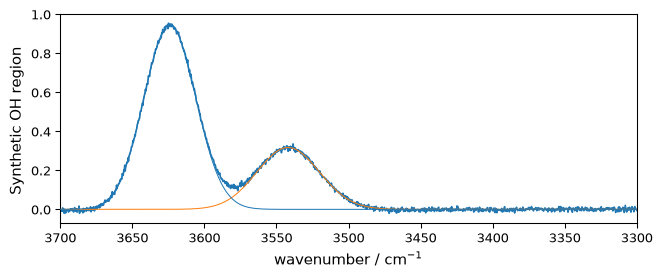

In [14]:
_ = nd_oh_corr.plot()
ax = components[:].plot(clear=False)
ax.autoscale(enable=True, axis="y")

`plotmerit()` overlays the corrected spectrum, the fitted profile, and the
residuals. As in the fitting tutorial, we use a small residual offset to keep
the comparison readable in a notebook, with short legend labels to avoid
crowding the compact tutorial figure.

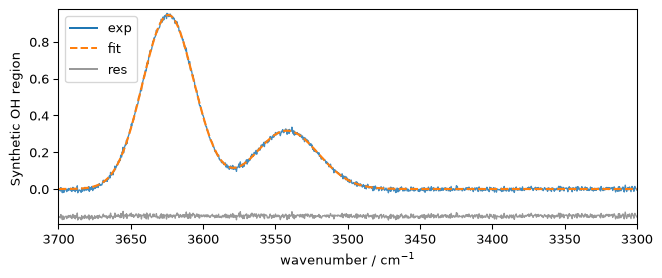

In [15]:
_ = opt.plotmerit(
    offset=15,
    exp_label="exp",
    calc_label="fit",
    resid_label="res",
    legend_loc="upper left",
)

## Summary

This workflow now has a clear progression:

- `find_peaks()` detects candidates,
- `PeakFindingResult` stores the structured detection output,
- `PeakTable` provides a stable tabular view for inspection and export,
- `Optimize.validate_script()` checks the fitting DSL before optimization,
- `FitResult` groups fitted outputs and diagnostics.

This is the current reference workflow when moving from peak detection to peak
fitting in SpectroChemPy.